In [261]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions 
from sklearn.ensemble import RandomForestClassifier


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Features (Fixed)
1) Relative Pricing	
- (price / average pricing) of listings with same conditions (same neighborhood, # of bedrooms and bathrooms, and roomtype)
2) Housing Characteristics:
- Room Type 
- num of Bedrooms
- num of Bathrooms
- num of Beds
- num of Accommodates
- Is_Long_term: 1 if minimum_nights > 7, 0 if minimum_nights <= 7
3) Host Characteristics:
- Host_Response TIme
- Host_Identity_Verified
4) Other Users Experience/Engagement:
- number_of_reviews (TBD vvn: check the colinearity btw scoring and num of review)
- recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
- estimated_occupancy_l365d


In [220]:
sea = pd.read_csv("seattle_filtered.csv")

In [222]:
# create relative price columns
# Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
sea["avg_price_group"] = sea.groupby(group_cols)["price"].transform("mean")
sea["relative_price"] = sea["price"] / sea["avg_price_group"]

In [223]:
# host response time
mapping_host_response_time = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

sea['host_response_time'] = sea['host_response_time'].map(mapping_host_response_time)

In [224]:
# is_long_term
## minimum nights -> short-term listing vs. long-term listing
sea['is_long_term'] = (sea["minimum_nights"] > 7).astype(int)

In [225]:
# recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
sea['recent_Review_proportion'] = sea['number_of_reviews_ltm'] / sea['number_of_reviews']

In [226]:
features = [
    "review_scores_rating",
    # relative pricing
    "relative_price",
    # housing characteristics
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "room_type",
    "is_long_term",
    # host characteristics
    "host_response_time",
    "host_identity_verified", 
    # others
    "number_of_reviews",
    "recent_Review_proportion",
    "estimated_occupancy_l365d"
]

In [227]:
df_sea = sea[features]
# drop na
df_drop = df_sea.dropna()
# fill na with 0
df_sea = df_sea.fillna(0)

In [228]:
sea.shape

(6072, 83)

In [229]:
df_sea.shape

(6072, 13)

In [230]:
df_drop.shape

(4872, 13)

### Prediction Rating Score (KNN)

In [28]:
# create relative price columns
# Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
seattle["avg_price_group"] = seattle.groupby(group_cols)["price"].transform("mean")
seattle["relative_price"] = seattle["price"] / seattle["avg_price_group"]

In [88]:
features = [
    
    # relative pricing
    "relative_price",
    # housing characteristics
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "neighbourhood",
    "minimum_nights",
    "room_type",
    # host characteristics
    "host_response_time",
    # "host_is_superhost", 
    # others
    # "number_of_reviews",
    # "number_of_reviews_ltm",
    # "number_of_reviews_l30d"
]

In [89]:
df_sea = seattle[features]
df_sea = df_sea.fillna(0)
df_sea

,relative_price,bedrooms,beds,bathrooms,accommodates,neighbourhood,minimum_nights,room_type,host_response_time
0,0.772909,1.0,1.0,1.0,1,Neighborhood highlights,30,Entire home/apt,within a few hours
1,0.984592,1.0,2.0,3.0,2,Neighborhood highlights,2,Private room,within an hour
3,1.232497,3.0,3.0,2.0,8,0,30,Entire home/apt,within a few hours
4,0.741860,1.0,2.0,1.0,4,Neighborhood highlights,2,Entire home/apt,within an hour
5,0.969773,2.0,3.0,1.0,3,Neighborhood highlights,30,Entire home/apt,within a few hours
...,...,...,...,...,...,...,...,...,...
6991,1.091398,1.0,1.0,1.5,2,0,1,Private room,0
6992,1.091398,1.0,1.0,1.5,2,0,1,Private room,0
6993,1.000000,1.0,1.0,1.0,2,0,3,Private room,within a few hours
6994,1.073869,1.0,1.0,1.0,2,0,30,Entire home/apt,0


#### Training Model (replace nan with 0)

In [231]:
# target variable: review_score_rating
## high v.s. low score: scores >= 4.9
y = (df_sea["review_scores_rating"] >= 4.9).astype(int)

In [232]:
y.value_counts()

review_scores_rating
0    3274
1    2798
Name: count, dtype: int64

In [233]:
print(f"Baseline Accuracy: ",3274 / (3274+2798))

Baseline Accuracy:  0.5391963109354414


In [237]:
X = df_sea.drop(columns=["review_scores_rating"])
X = pd.get_dummies(X, drop_first = True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [238]:
X

,relative_price,bedrooms,beds,bathrooms,accommodates,is_long_term,host_response_time,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d,room_type_Private room,room_type_Shared room,host_identity_verified_f,host_identity_verified_t
0,0.772909,1.0,1.0,1.0,1,1,2.0,161,0.000000,0,False,False,False,True
1,0.984592,1.0,2.0,3.0,2,0,1.0,220,0.063636,84,True,False,False,True
2,1.232497,3.0,3.0,2.0,8,1,2.0,98,0.000000,0,False,False,False,True
3,0.741860,1.0,2.0,1.0,4,0,1.0,1139,0.054434,255,False,False,False,True
4,0.969773,2.0,3.0,1.0,3,1,2.0,64,0.000000,0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6067,1.091398,1.0,1.0,1.5,2,0,0.0,0,0.000000,0,True,False,False,True
6068,1.091398,1.0,1.0,1.5,2,0,0.0,0,0.000000,0,True,False,False,True
6069,1.000000,1.0,1.0,1.0,2,0,2.0,0,0.000000,0,True,False,True,False
6070,1.073869,1.0,1.0,1.0,2,1,0.0,0,0.000000,0,False,False,False,False


##### Deciding k-values (k = 43)

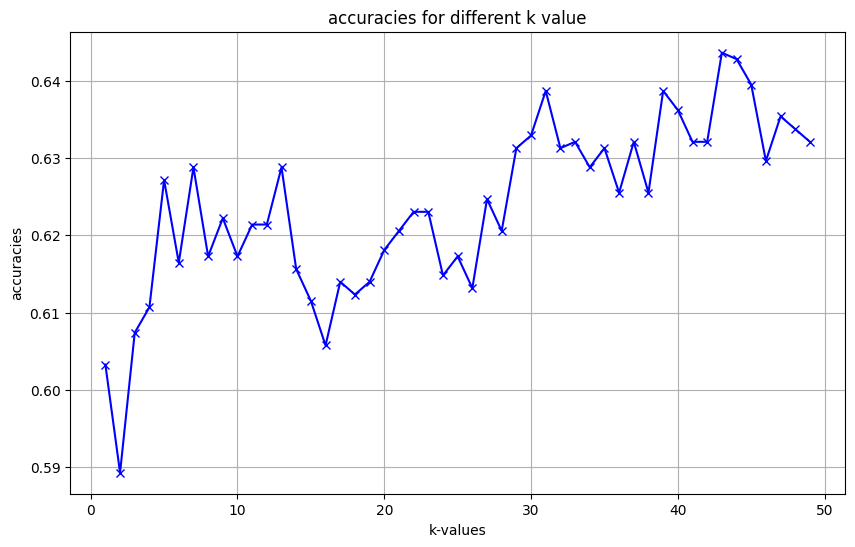

In [244]:
k_values = range(1, 50)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

# data viz
x = np.arange(1,50)
plt.figure(figsize=(10, 6))
plt.plot(x, accuracies, 'bx-')
plt.xlabel('k-values')
plt.ylabel('accuracies')
plt.title('accuracies for different k value')
plt.grid(True)
plt.show()

##### Model Performance

In [245]:
clf = KNeighborsClassifier(n_neighbors= 43)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Calculate precision
precision = precision_score(y_test, y_pred)

# Evaluate the model
print("\nAccuracy:")
print(clf.score(X_test, y_test))
print("\nPrecision Score:")
print(precision)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy:
0.6436213991769547

Precision Score:
0.6177924217462932

Confusion Matrix:
[[407 232]
 [201 375]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.64      0.65       639
           1       0.62      0.65      0.63       576

    accuracy                           0.64      1215
   macro avg       0.64      0.64      0.64      1215
weighted avg       0.64      0.64      0.64      1215

